# Compare apparent melting temperatures to predicted expression values for Omi32 and its germline sequence, along with another selected intermediate from the library

The 'geno' column of the input file gives the binary genotype string for each antibody tested, where 0 represents a wild-type (germline) amino acid and 1 represents a mature (bnAb) amino acid for all 13 amino acid substitutions between the Omi32 bnAb and its germline sequence.

Delta melting temperatures are calculated for each replicate, and the delta between Omi32 and the selected intermediate from germline are calculated for each replicate and then averaged.

Average melting temperature differences from germline and predicted expression values are then plotted along with SEM error bars for melting temperatures and prediction error for expression.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

In [8]:
# load dataframe (also shows the exact binary genotype for the selected intermediate antibody sequence)
df = pd.read_csv('data/tm_vals_omi32.csv')
df['geno'] = df['geno'].astype(str).str.zfill(13)
print(df)

  shortname           geno   tm_1   tm_2   tm_3  expression  expression_sem
0  germline  0000000000000  80.53  85.29  88.72    4.227666        0.014119
1     Omi32  1111111111111  66.80  72.07  76.83    4.324298        0.014097
2      5377  1010100010100  67.40  72.19  76.43    4.202193        0.014109


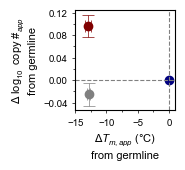

In [12]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

germline = df[df['shortname'] == 'germline'].iloc[0]
variants = df[df['shortname'] != 'germline'].copy()

tm_cols = ['tm_1', 'tm_2', 'tm_3']

variants['delta_tm_mean'] = variants.apply(
    lambda row: np.mean([row[c] - germline[c] for c in tm_cols]), axis=1
)
variants['delta_tm_sem'] = variants.apply(
    lambda row: np.std([row[c] - germline[c] for c in tm_cols], ddof=1) / np.sqrt(len(tm_cols)), axis=1
)

variants['delta_expression'] = variants['expression'] - germline['expression']
variants['delta_expression_sem'] = np.sqrt(variants['expression_sem']**2 + germline['expression_sem']**2)

color_map = {
    'Omi32': '#800000',
    '5377': 'gray',
    'germline': '#000080'
}

plot_width = 1
plot_height = 1

left_margin = 0.6
right_margin = 0.15
top_margin = 0.15
bottom_margin = 0.5

fig_width = plot_width + left_margin + right_margin
fig_height = plot_height + top_margin + bottom_margin

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
fig.subplots_adjust(
    left=left_margin / fig_width,
    right=1 - right_margin / fig_width,
    top=1 - top_margin / fig_height,
    bottom=bottom_margin / fig_height
)

for _, row in variants.iterrows():
    color = color_map.get(str(row['shortname']), 'black')
    ax.errorbar(
        row['delta_tm_mean'], row['delta_expression'],
        xerr=row['delta_tm_sem'], yerr=row['delta_expression_sem'],
        fmt='o', color=color, ecolor=color,
        markersize=6, linewidth=0.5,
        capsize=4, capthick=0.5,
        label=row['shortname']
    )

# Germline point at origin by definition
ax.plot(0, 0, 'o', color='#000080', markersize=6, label='germline')

ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

ax.set_xlabel('Δ$T_{m, app}$ (°C)\nfrom germline', fontsize=8)
ax.set_ylabel('Δ $\\log_{10}$ copy #$_{\mathit{app}}$\nfrom germline', fontsize=8)

# Y-axis ticks
ax.set_yticks([-0.04, 0, 0.04, 0.08, 0.12])
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

# X-axis ticks
ax.set_xticks([-15, -10, -5, 0])
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

# Tick label font
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname('Arial')
    label.set_fontsize(7)

# Ticks: outward, 0.5pt width, length 2 major / 1 minor
ax.tick_params(which='both', width=0.5, direction='out')
ax.tick_params(which='major', length=2)
ax.tick_params(which='minor', length=1.5)
ax.set_xlim(-15, 1)
#ax.legend(fontsize=7, prop={'family': 'Arial', 'size': 7})
plt.savefig('S_Figure_2b.png', dpi=2000, bbox_inches='tight', transparent=True)
plt.show()